In [104]:
import pandas as pd
import numpy as nm

In [105]:
df=pd.read_csv('Fraud_Analysis_Dataset.csv')

In [106]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


In [108]:
df.shape

(11142, 10)

In [109]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [110]:
import matplotlib.pyplot as plt

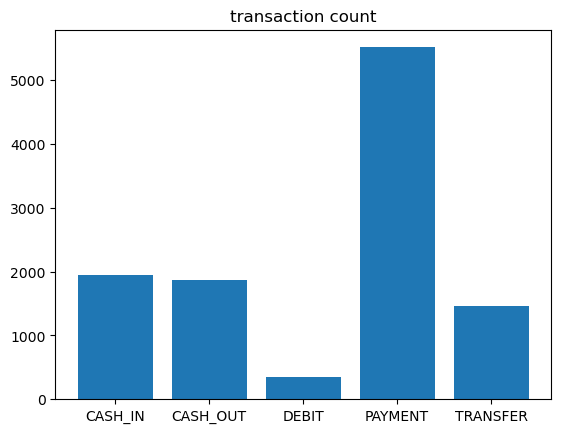

In [111]:
import seaborn as sns
type_tr=df['type'].value_counts().sort_index()
plt.bar(type_tr.index,type_tr.values,label=True)
plt.title('transaction count')
plt.show()

In [112]:
fraud_count=df[df['isFraud']==1]['type'].value_counts()
fraud_count

type
CASH_OUT    578
TRANSFER    564
Name: count, dtype: int64

In [113]:
df[df['isFraud']==1]['type'].value_counts()

type
CASH_OUT    578
TRANSFER    564
Name: count, dtype: int64

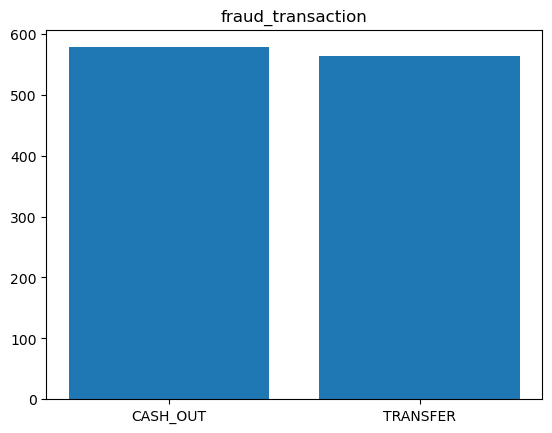

In [114]:
plt.bar(x=fraud_count.index,height=fraud_count.values)
plt.title('fraud_transaction')
plt.show()

In [115]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [116]:
#df=pd.get_dummies(df,axis=1,dtype='int')
x=df.drop(['step','nameOrig','nameDest','step','isFraud'],axis=1)
y=df['isFraud']

In [117]:
x.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
0,TRANSFER,181.0,181.0,0.0,0.0,0.0
1,CASH_OUT,181.0,181.0,0.0,21182.0,0.0
2,TRANSFER,2806.0,2806.0,0.0,0.0,0.0
3,CASH_OUT,2806.0,2806.0,0.0,26202.0,0.0
4,TRANSFER,20128.0,20128.0,0.0,0.0,0.0


In [118]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: isFraud, dtype: int64

In [119]:
df=pd.get_dummies(data=x,dtype='int',drop_first=True)
df.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,181.0,181.0,0.0,0.0,0.0,0,0,0,1
1,181.0,181.0,0.0,21182.0,0.0,1,0,0,0
2,2806.0,2806.0,0.0,0.0,0.0,0,0,0,1
3,2806.0,2806.0,0.0,26202.0,0.0,1,0,0,0
4,20128.0,20128.0,0.0,0.0,0.0,0,0,0,1


In [120]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [121]:
x_scale=scaler.fit_transform(df)
x_scale

array([[-0.28026556, -0.43115999, -0.39475428, ..., -0.17902209,
        -0.98910974,  2.57111955],
       [-0.28026556, -0.43115999, -0.39475428, ..., -0.17902209,
        -0.98910974, -0.38893563],
       [-0.27681175, -0.42993502, -0.39475428, ..., -0.17902209,
        -0.98910974,  2.57111955],
       ...,
       [ 0.27626264, -0.37156334, -0.39475428, ..., -0.17902209,
        -0.98910974, -0.38893563],
       [-0.27906425, -0.42474954, -0.38861782, ..., -0.17902209,
         1.01101017, -0.38893563],
       [-0.26835212, -0.4125955 , -0.38005076, ..., -0.17902209,
         1.01101017, -0.38893563]])

In [54]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scale,y,test_size=0.2,random_state=70)

In [86]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(C=10,max_iter=1000)

In [87]:
# for c in [0.01,0.1,10,100]:
#     model=LogisticRegression(C=c,max_iter=1000)
#     model.fit(x_train,y_train)
#     print(f'C={c}, train_accuracy={accuracy_score(y_train,model.predict(x_train)):.3f}, test_accuracy={accuracy_score(y_test,model.predict(x_test)):.3f}')

In [122]:
from sklearn.preprocessing import PolynomialFeatures
model_poly=PolynomialFeatures(degree=2,include_bias=False)

In [98]:
print("Original X:\n", x_train)
print("Transformed X (degree=2):\n", model_poly)
print("Feature names:", model_poly.get_feature_names_out())

Original X:
 [[-0.27294559 -0.41914641 -0.38509757 ... -0.17902209  1.01101017
  -0.38893563]
 [ 0.22128021  2.43980293  2.73174629 ... -0.17902209 -0.98910974
  -0.38893563]
 [-0.27540338 -0.39958094 -0.36414103 ... -0.17902209  1.01101017
  -0.38893563]
 ...
 [-0.26943126 -0.39092437 -0.35743644 ... -0.17902209  1.01101017
  -0.38893563]
 [-0.2800105  -0.43124446 -0.39475428 ... -0.17902209  1.01101017
  -0.38893563]
 [-0.24441835 -0.43124446 -0.39475428 ... -0.17902209 -0.98910974
  -0.38893563]]
Transformed X (degree=2):
 PolynomialFeatures(include_bias=False)
Feature names: ['x0' 'x1' 'x2' 'x3' 'x4' 'x5' 'x6' 'x7' 'x8' 'x0^2' 'x0 x1' 'x0 x2'
 'x0 x3' 'x0 x4' 'x0 x5' 'x0 x6' 'x0 x7' 'x0 x8' 'x1^2' 'x1 x2' 'x1 x3'
 'x1 x4' 'x1 x5' 'x1 x6' 'x1 x7' 'x1 x8' 'x2^2' 'x2 x3' 'x2 x4' 'x2 x5'
 'x2 x6' 'x2 x7' 'x2 x8' 'x3^2' 'x3 x4' 'x3 x5' 'x3 x6' 'x3 x7' 'x3 x8'
 'x4^2' 'x4 x5' 'x4 x6' 'x4 x7' 'x4 x8' 'x5^2' 'x5 x6' 'x5 x7' 'x5 x8'
 'x6^2' 'x6 x7' 'x6 x8' 'x7^2' 'x7 x8' 'x8^2']


In [126]:
poly=model_poly.fit_transform(x_scale)

In [127]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(poly,y,test_size=0.2,random_state=70)

In [128]:
model.fit(x_train,y_train)

LogisticRegression(C=10, max_iter=1000)

In [130]:
pred_py=model.predict(x_train)
pred_tt_py=model.predict(x_test)
print(accuracy_score(y_train,pred_py))
print(accuracy_score(y_test,pred_tt_py))

0.9800291708740043
0.9775684163301929


In [ ]:
tr_py=accuracy

In [88]:
model.fit(x_train,y_train)

LogisticRegression(C=10, max_iter=1000)

In [89]:
y_pred_tr=model.predict_proba(x_train)
y_pred_tt=model.predict_proba(x_test)

In [90]:
y_pd_tr=model.predict(x_train)
y_pd_tt=model.predict(x_test)

In [91]:
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,roc_auc_score

In [92]:
cl_score=classification_report(y_test,y_pd_tt)
print('classification_report',cl_score)
print('accuracy',accuracy_score(y_test,y_pd_tt))
print('precision',precision_score(y_test,y_pd_tt))
print('recall',recall_score(y_test,y_pd_tt))

classification_report               precision    recall  f1-score   support

           0       0.96      1.00      0.98      1994
           1       0.96      0.68      0.80       235

    accuracy                           0.96      2229
   macro avg       0.96      0.84      0.89      2229
weighted avg       0.96      0.96      0.96      2229

accuracy 0.9636608344549125
precision 0.963855421686747
recall 0.6808510638297872


In [93]:
print('roc-auc:',roc_auc_score(y_test,y_pred_tt[:,1]))

roc-auc: 0.9923493885913057


In [94]:
from sklearn.metrics import roc_curve
fpr,tpr,threshold=roc_curve(y_test,y_pred_tt[:,1])
roc_auc=roc_auc_score(y_test,y_pred_tt[:,1])

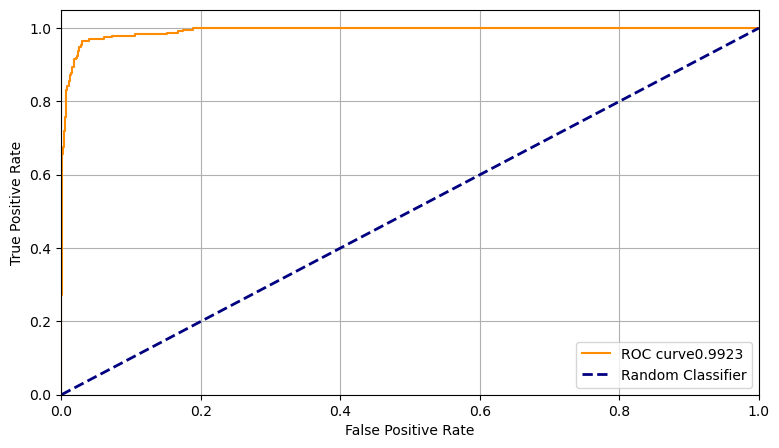

In [95]:
plt.figure(figsize=(9,5))
plt.plot(fpr,tpr,color='darkorange',label=f'ROC curve{roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()